In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [66]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export_fuel_calamp.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13052 entries, 0 to 13051
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  13052 non-null  str  
 1   Message  13052 non-null  str  
 2   Status   13052 non-null  str  
dtypes: str(3)
memory usage: 306.0 KB


In [67]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [68]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
fs01_raw_data=[]
date_fs02_dec_value=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')       
    if aux>109:
        fs01=(e0x_aux[110:180])
        #print(fs01,aux)
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            fs01_raw_data.append(e0x.iloc[i,2])            
            msb=fs01[28:30]
            lsb=fs01[26:28]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            fs01_raw_data.append(e0x.iloc[i,2])
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            fs01_raw_data.append(e0x.iloc[i,2])
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            fs01_raw_data.append(e0x.iloc[i,2])
            msb=fs01[64:66]
            lsb=fs01[62:64]
            last_index_fs01=i        
            
#print(i, raw_fuel_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if aux>109:
        fs02=e0x_aux[110:180]
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            fs02_dec_value.append(int(measure,16))            
            msb=fs02[28:30]
            lsb=fs02[26:28]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            fs01_dec_value.append(int(measure,16)) 
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            fs01_dec_value.append(int(measure,16))
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            fs01_dec_value.append(int(measure,16))
            msb=fs02[64:66]
            lsb=fs02[62:64]
            #last_index_fs02=i        
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value

print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])        


Last fuel report fs01:  2026-05-28 17:23:07.325 Last fuel report fs02:  Series([], Name: Created, dtype: str)


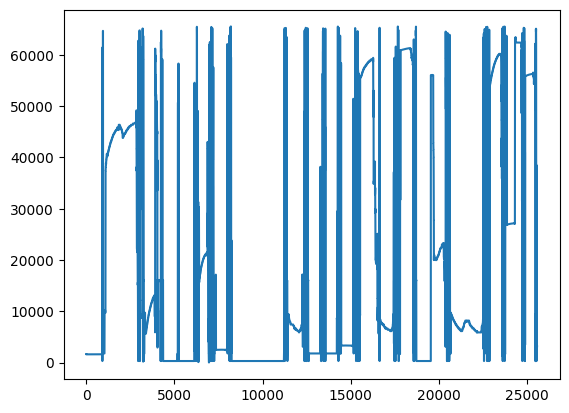

In [69]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [65]:
for i in range(0,values_dates_fs01.shape[0]):
    if int(values_dates_fs01.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i,2],values_dates_fs01.iloc[i,0])

0x83054764434380010101040CC569F62F9569F62F95FDC6C369D454794C00002EB2000000D8008B0E00000AFFAF4F073700000500240726FE0EEFCC3E010726FE0EE3E03E010726160F6BF1E43E010726160F60F1F83E010726 16076
0x83054764434380010101040CC569F62F9569F62F95FDC6C369D454794C00002EB2000000D8008B0E00000AFFAF4F073700000500240726FE0EEFCC3E010726FE0EE3E03E010726160F6BF1E43E010726160F60F1F83E010726 16076
0x83054764434380010101040CC569F62F9569F62F95FDC6C369D454794C00002EB2000000D8008B0E00000AFFAF4F073700000500240726FE0EEFCC3E010726FE0EE3E03E010726160F6BF1E43E010726160F60F1F83E010726 16076
0x83054764434380010101040CC569F62F9569F62F95FDC6C369D454794C00002EB2000000D8008B0E00000AFFAF4F073700000500240726FE0EEFCC3E010726FE0EE3E03E010726160F6BF1E43E010726160F60F1F83E010726 16076
0x83054764434380010101040CD069F6321569F63215FDC532E2D455AF9E00002E0A000000A300210D00000AFFBD4F081700000500240EFFFF3E010726FF0EF6C73E010726030F39F0E93E010726060F60F0F83E010726150F54 9735
0x83054764434380010101040CD069F6321569F63215FDC532E2D455AF9E00002E

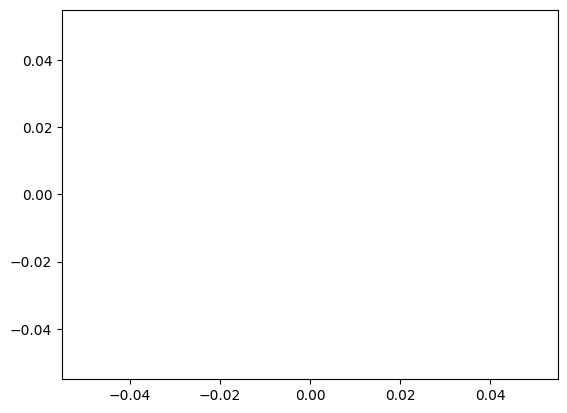

In [62]:
plt.plot(fs02_x_values,fs02_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [70]:
for i in range(0,values_dates_fs02.shape[0]):
    if int(values_dates_fs02.iloc[i,0])>4095:
        print(values_dates_fs02.iloc[i,2],values_dates_fs02.iloc[i,0])